In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

In [12]:
TEMP = 23 #celcius
HUMIDITY = 61 #%
PRESSURE = 992e2 / 133.322387415 #mmhg
DENSITY = (0.46455 * PRESSURE - HUMIDITY * (0.00252 * TEMP - 0.020582)) / (TEMP + 273.15) #kg/m3
print(DENSITY)

H_ATM = 136
H_PITOT = 14.65
CORDLENGTH = 150

plot_configs = [
    ('0', 0, 'indianred'),
    ('6', 6, 'steelblue'),
    ('m4', -4, 'lightseagreen')
]

1.1594581064279144


In [13]:
df = pd.read_csv('downstream.csv')

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_9091/3245093027.py:8: SyntaxWarning: invalid escape sequence '\m'
  label=f'$\mathrm{{AOA}}={aoa_val}^\circ$', marker='o', color=color, markersize=5, lw=1)
/tmp/ipykernel_9091/3245093027.py:8: SyntaxWarning: invalid escape sequence '\c'
  label=f'$\mathrm{{AOA}}={aoa_val}^\circ$', marker='o', color=color, markersize=5, lw=1)


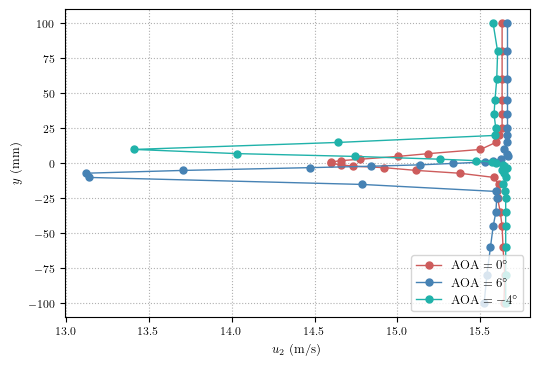

In [16]:
fig, ax = plt.subplots(figsize=(6,4))

for suffix, aoa_val, color in plot_configs:
    df[f'dp{suffix}'] = 1000 * 9.81 * df[f'aoa{suffix}'] * 0.001
    df[f'u2{suffix}'] = np.sqrt(2 * df[f'dp{suffix}'] / DENSITY)

    ax.plot(df[f'u2{suffix}'], df['loc'],
            label=f'$\mathrm{{AOA}}={aoa_val}^\circ$', marker='o', color=color, markersize=5, lw=1)
    
ax.set_xlabel('$u_2$ (m/s)')
ax.set_ylabel('$y$ (mm)')
ax.legend(loc='lower right')
ax.grid(True, linestyle=':')

#fig.savefig('cp.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [17]:
drag_results = {}

for suffix, aoa_val, color in plot_configs:
    u_array = df[f'v{suffix}'].values
    y_array = df['loc'].values * 0.001
    
    u1 = np.max(u_array)
    d_prime = 0
    
    for i in range(len(y_array) - 1):
        dy = abs(y_array[i] - y_array[i+1])
        u2_avg = (u_array[i] + u_array[i+1]) / 2
        d_prime += DENSITY * u2_avg * (u1 - u2_avg) * dy
        
    drag_results[f'AOA_{aoa_val}'] = d_prime

for k, v in drag_results.items():
    print(f"{k}: {v:.4f} N/m")

AOA_0: 0.2731 N/m
AOA_6: 0.6293 N/m
AOA_-4: 0.4748 N/m
